In [3]:
# Load the ECG data
data = np.loadtxt('data/ECGu.txt')

# Display it
print (data)
print("Number of points:", len(data))

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
Number of points: 6500


# Arrival point : 
Detect heartbeats and compute heart rate from the raw ECG signal.

# Starting point : 
Raw voltage values loaded from 'ECGu.txt'

# Steps : 
1. Load the data
2. Plot the raw ECG data
3. Convert to mV / seconds
4. Plot rescaled data 
5. Rename vars, refactor, docstrings


In [4]:
import numpy as np  
import matplotlib.pyplot as plt

In [9]:
raw_ecg = np.loadtxt('data/ECGu.txt')

In [10]:
print(raw_ecg)
print(raw_ecg.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


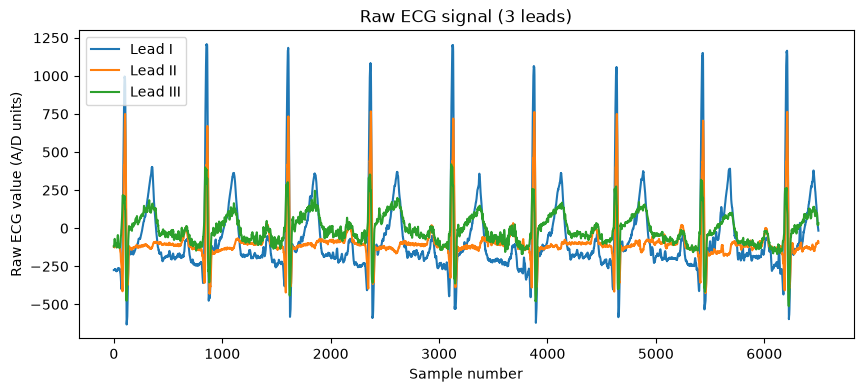

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(raw_ecg)
plt.xlabel("Sample number")
plt.ylabel("Raw ECG value (A/D units)")
plt.title("Raw ECG signal (3 leads)")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

plt.figure(figsize=(10, 4)) - Crée une nouvelle figure (une nouvelle "fenêtre" de graphique) avec une taille de 10 pouces de large sur 4 pouces de haut. Sans ça, matplotlib utiliserait une taille par défaut (souvent trop petite/carrée), ce qui rendrait un signal ECG (qui s'étale sur l'axe du temps) difficile à lire.

plt.plot(raw_ecg) - Trace le graphique. raw_ecg est un tableau numpy de forme (6500, 3) — 6500 lignes (échantillons), 3 colonnes (leads I, II, III). Quand tu donnes un tableau 2D à plt.plot(), matplotlib trace automatiquement une courbe par colonne, en utilisant l'index de ligne (0, 1, 2, ..., 6499) comme axe des x. Résultat : 3 courbes superposées sur le même graphique, une par lead.

plt.xlabel("Sample number") - Ajoute un texte sous l'axe horizontal (x) pour dire ce qu'il représente : ici, le numéro de l'échantillon (0 à 6499), puisqu'on n'a pas encore converti ça en secondes.

plt.ylabel("Raw ECG value (A/D units)") : Ajoute un texte à côté de l'axe vertical (y) : les valeurs tracées sont les valeurs brutes du convertisseur analogique-numérique (A/D), pas encore converties en millivolts (d'où "raw" et "A/D units" — pas encore une unité physique réelle).

plt.title("Raw ECG signal (3 leads)") : Ajoute un titre en haut du graphique, pour que n'importe qui comprenne immédiatement ce que montre la figure sans avoir à lire le code.


plt.legend(["Lead I", "Lead II", "Lead III"]) : Ajoute une légende (petite boîte) qui associe chaque couleur de courbe à un nom. Comme plt.plot() a tracé 3 courbes dans l'ordre des colonnes de raw_ecg, cette liste doit être dans le même ordre : colonne 0 = Lead I, colonne 1 = Lead II, colonne 2 = Lead III.

plt.show() : Affiche le graphique final à l'écran.

In [15]:
print("Min value:", raw_ecg.min())
print("Max value:", raw_ecg.max())

Min value: -632.0
Max value: 1206.0


# Check : 
The plot shows 3 overlapping curves, one per lead, which matches raw_ecg.shape = (6500, 3). 
The x-axis goes up to 6500 samples as expected. 
The y-axis values range roughly from -500 to 1250, which is 
consistent with value check just performed. The signal shows a repeating pattern typical of heartbeats, rather than random noise, which suggests the data was loaded and plotted correctly.

In [16]:
# Convert raw ECG values to millivolts
# A/D converter gain: 1024 µV per unit
AD_GAIN_UV = 1024  # microvolts per raw unit
ecg_mV = raw_ecg * AD_GAIN_UV / 1000  # convert to millivolts

In [17]:
# Build the time axis in seconds
# Sampling frequency: 1000 Hz
SAMPLING_FREQ_HZ = 1000
n_samples = raw_ecg.shape[0]
time_axis_s = np.arange(n_samples) / SAMPLING_FREQ_HZ

n_samples = raw_ecg.shape[0] : Récupère le nombre total d'échantillons dans tes données.
raw_ecg.shape donne la forme complète du tableau, ici (6500, 3).
.shape[0] prend le premier élément de ce tuple (collection ordonnée de valeurs entre parenthèses : 6500 = nb lignes et 3 = nb colonnes), donc 6500 — le nombre de lignes (= nombre d'échantillons dans le temps). 